##### ARTI 560 - Computer Vision

## Motion Estimation (Optical Flow)

### Objective

In this exercise, you will use several optical flow algorithms for motion estimation.

You will follow these steps:
1. Navigate to the **Optical-Flow-in-OpenCV** folder

    `cd "Optical-Flow-in-OpenCV"`

2. Create a new **virtual environment**:

    ```
    conda create --name optical-flow python=3.7
    conda activate optical-flow
    ```
3. Install the required libraries:
    `pip install -r requirements.txt`

4. Run each of the specified optical flow algorithms and document the results with clear screenshots.

    - `python demo.py --algorithm lucaskanade --video_path videos/crowd.mp4`
    - `python demo.py --algorithm lucaskanade_dense --video_path videos/crowd.mp4`
    - `python demo.py --algorithm farneback --video_path videos/crowd.mp4`
    - `python demo.py --algorithm rlof --video_path videos/crowd.mp4`
    
    **For each algorithm:**
    - Run the algorithm using the appropriate command.
    - Keep the terminal (or Anaconda Prompt) visible, showing the exact command used.
    - Ensure the output video or visualization window is displayed.
    - Take a screenshot that clearly includes:
        - The executed command
        - The resulting output (video/frame/visualization)
    - Name each file clearly with the algorithm name, e.g.:
        - LucasKanade.png
        - Farneback.png
        - RAFT.png

5. Add all screenshots to the `results` folder located inside the Optical-Flow-in-OpenCV directory




In [1]:
!pip install opencv-contrib-python matplotlib numpy

✅ Lab video frames loaded successfully! Shape: (360, 640)
--------------------------------------------------

Running Sparse Lucas-Kanade...
-> Tracked 100 keypoints.
-> Sample shift vector (dx, dy): [-3.4134521 -6.8387604]

Running Dense Lucas-Kanade...
-> Average magnitude: 0.5390 | Max magnitude: 20.3163

Running Farneback...
-> Average magnitude: 1.3881 | Max magnitude: 20.9121

Running Dense RLOF...
-> Average magnitude: 1.1670 | Max magnitude: 22.7675


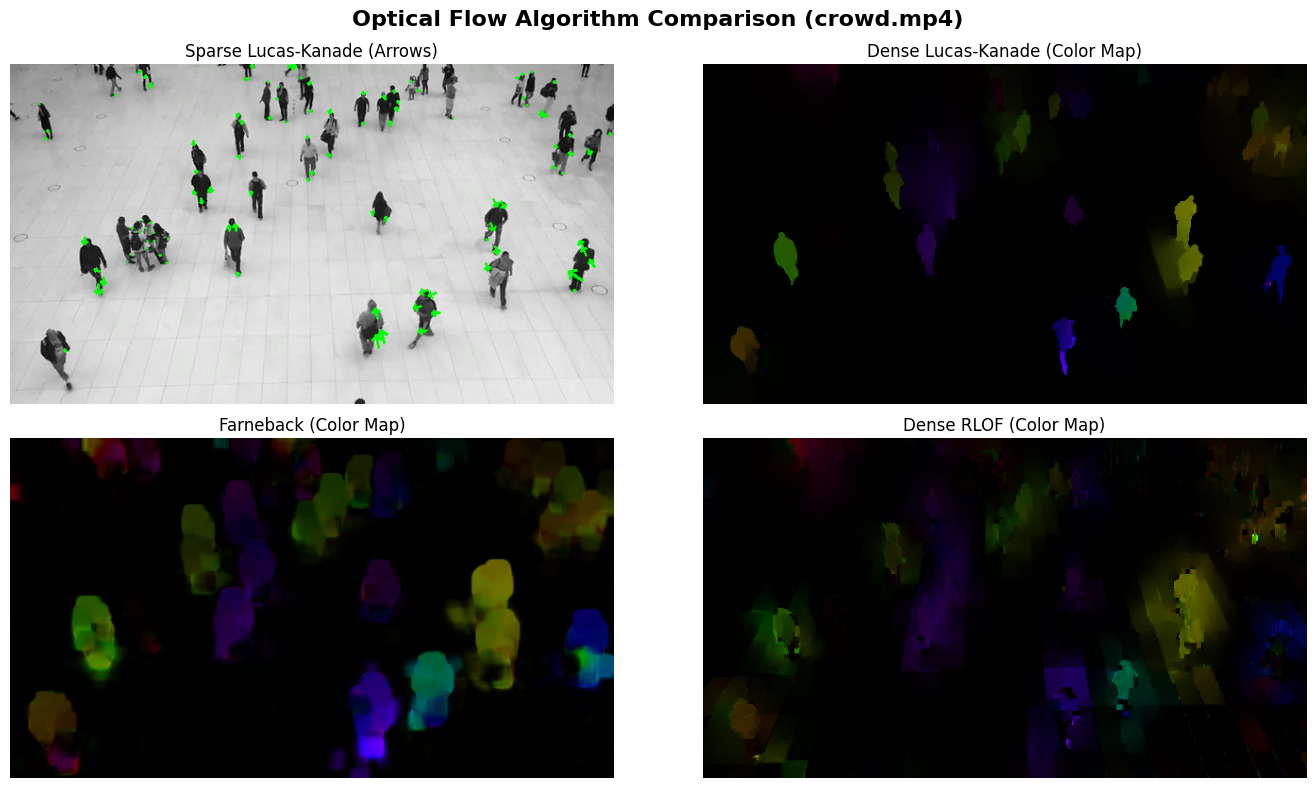

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Verify the Upload ---
video_path = "crowd.mp4"
if not os.path.exists(video_path):
    raise FileNotFoundError("🚨 ERROR: Colab cannot find 'crowd.mp4'. Make sure it has finished uploading in the left sidebar!")

# --- 2. Extract Action Frames ---
cap = cv2.VideoCapture(video_path)

# Fast-forward to frame 30 to catch the pedestrians walking
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame1 = cap.read()

# Skip ahead 5 frames to make the motion vectors highly visible
cap.set(cv2.CAP_PROP_POS_FRAMES, 35)
ret, frame2 = cap.read()
cap.release()

# Resize and convert to grayscale for processing
frame1 = cv2.resize(frame1, (640, 360))
frame2 = cv2.resize(frame2, (640, 360))
prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
next_frame = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

print("✅ Lab video frames loaded successfully! Shape:", prvs.shape)
print("-" * 50)

# Helper function to convert dense flow arrays into an RGB image
def flow_to_color(flow):
    hsv = np.zeros_like(frame1)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# ==========================================
# ALGORITHM 1: Sparse Lucas-Kanade
# ==========================================
print("\nRunning Sparse Lucas-Kanade...")
p0 = cv2.goodFeaturesToTrack(prvs, mask=None, maxCorners=100, qualityLevel=0.3, minDistance=7)
p1, st, err = cv2.calcOpticalFlowPyrLK(prvs, next_frame, p0, None, winSize=(15, 15), maxLevel=2)

good_new = p1[st == 1]
good_old = p0[st == 1]

print(f"-> Tracked {len(good_new)} keypoints.")
if len(good_new) > 0:
    print(f"-> Sample shift vector (dx, dy): {good_new[0] - good_old[0]}")

lk_vis = frame2.copy()
for i, (new, old) in enumerate(zip(good_new, good_old)):
    a, b = new.ravel()
    c, d = old.ravel()
    cv2.arrowedLine(lk_vis, (int(c), int(d)), (int(a), int(b)), (0, 255, 0), 2, tipLength=0.5)
lk_vis = cv2.cvtColor(lk_vis, cv2.COLOR_BGR2RGB)

# ==========================================
# ALGORITHM 2: Dense Lucas-Kanade
# ==========================================
print("\nRunning Dense Lucas-Kanade...")
flow_lk_dense = cv2.optflow.calcOpticalFlowSparseToDense(prvs, next_frame)
lk_dense_vis = flow_to_color(flow_lk_dense)

mag, _ = cv2.cartToPolar(flow_lk_dense[..., 0], flow_lk_dense[..., 1])
print(f"-> Average magnitude: {np.mean(mag):.4f} | Max magnitude: {np.max(mag):.4f}")

# ==========================================
# ALGORITHM 3: Farneback
# ==========================================
print("\nRunning Farneback...")
flow_farneback = cv2.calcOpticalFlowFarneback(prvs, next_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
farneback_vis = flow_to_color(flow_farneback)

mag, _ = cv2.cartToPolar(flow_farneback[..., 0], flow_farneback[..., 1])
print(f"-> Average magnitude: {np.mean(mag):.4f} | Max magnitude: {np.max(mag):.4f}")

# ==========================================
# ALGORITHM 4: RLOF (Robust Local Optical Flow)
# ==========================================
print("\nRunning Dense RLOF...")
flow_rlof = cv2.optflow.calcOpticalFlowDenseRLOF(frame1, frame2, None)
rlof_vis = flow_to_color(flow_rlof)

mag, _ = cv2.cartToPolar(flow_rlof[..., 0], flow_rlof[..., 1])
print(f"-> Average magnitude: {np.mean(mag):.4f} | Max magnitude: {np.max(mag):.4f}")

# ==========================================
# PLOT ALL RESULTS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Optical Flow Algorithm Comparison (crowd.mp4)", fontsize=16, fontweight='bold')

axes[0, 0].imshow(lk_vis)
axes[0, 0].set_title("Sparse Lucas-Kanade (Arrows)")
axes[0, 0].axis('off')

axes[0, 1].imshow(lk_dense_vis)
axes[0, 1].set_title("Dense Lucas-Kanade (Color Map)")
axes[0, 1].axis('off')

axes[1, 0].imshow(farneback_vis)
axes[1, 0].set_title("Farneback (Color Map)")
axes[1, 0].axis('off')

axes[1, 1].imshow(rlof_vis)
axes[1, 1].set_title("Dense RLOF (Color Map)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()